<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_4_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integración numérica de ODEs

En este práctico introduciremos los métodos de **Euler** y de **RK4** (Runge-Kutta de orden 4) de integración numérica de Ecuaciones Diferenciales Ordinarias (ODEs).

## **Ejercicio 1)** Importando librerías

Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

In [ ]:
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

## **Ejercicio 2)** Integrador de **Euler**

**fotos en el celu**

### Ecuaciones Diferenciales Ordinarias (ODEs)

El comportamiento de un sistema dinámico se suele describir en términos de trayectorias. Una trayectoria es una función del tiempo

\begin{eqnarray}
x:\mathbb{R}\ni t\to x(t)\in X
\end{eqnarray}

en donde $x(t)\in X$ representa el estado que exhibe el sistema al tiempo $t$ y $X$ es un espacio vectorial.
Típicamente, $X=\mathbb{R}^n$.

Las trayectorias de un sistema dinámico suelen ser soluciones de una ecuación diferencial.
Nosotros, nos enfocaremos en sistemas dinámicos caracterizados por Ecuaciones Diferenciales Ordinarias (ODEs).

Decimos que una trayectoria $x:t\to x(t)$ es su solución de una ODE caracterizada por una función

\begin{eqnarray}
f: X,\mathbb{R} \ni x,t \to f(x,t) \in X
\end{eqnarray}

cuando

\begin{eqnarray}
x'(t) = f(x(t),t)
\end{eqnarray}

para todo tiempo $t$ perteneciente a algún intervalo de tiempo $ T\subseteq \mathbb{R}$. Aquí, $x'(t)$ es la derivada con respecto al tiempo $t$ de la función $x:t\to x(t)$ que representa la trayectoria.

En una ODE, una trayectoria particular $x$ queda unívocamente determinada por el valor de $x(t)$ en algún tiempo específico. Típicamente, se considera una *condición incial* $x(a)$, y nos interesa computar el valor de $x(t)$ para todo $t\in [a,b]$, i.e. conocer la trayectoria para todo tiempo entre un tiempo incial $a$ y un tiempo final $b$.

### Métodos de integración numérica de ODEs

Los métodos de integración de sistemas de Ecuaciones Diferenciales Ordinarias (ODEs) consisten, básicamente, de dos partes.

* Un método de extrapolación que permita aproximar **un paso de integración**, i.e. aproximar $x(t+h)$ a partir de conocer $t$, $x(t)$ y $f$ para valores de $h\in \mathbb{R}$ suficientementes pequeños.

* Un **integrador** de sucesivas aproximaciones $w_0$, $w_1$, ..., $w_k$ de los valores $x(a)$, $x(a+h)$, $x(a+2h)$, ..., $x(a+kh)=x(b)$ computadas secuencialmente a partir de un valor incial $w_0=x(a)$.

Existen varios métodos de aproximar un paso de integración.
En cambio, el integrador suele ser común a los diferentes métodos.

### Método de Euler

El método de Euler es, quizás, el más simple que existe.
Esencialmente, consiste en aproximar de $x(t+h)$ utilizando $f(x,t)$ para calcular la extrapolación lineal

\begin{eqnarray}
x(t+h)
&=&
x(t) + x'(t)h + x''(t)\frac{h^2}{2} + ...
\\
&\approx &
x(t) + x'(t)h
\\
&=&
x(t) + f(x(t),t)h
\end{eqnarray}

para un valor de $h$ que sea relativamente pequeño.

### Integrador

Si $t_0,t_1,...,t_n$ son valores equiespaciados en el intervalo de tiempo $[a,b]$, entonces $t_j=a+jh$ para $j\in \{0,1,2,...,n\}$ con $t_n=b$ y $h=(b-a)/n$.
Luego, utilizando el método $m$ proveido por el usuario, se computan sucesivamente las aproximaciones

\begin{eqnarray}
w_{j} &=& m(f,w_{j-1},t_{j-1},h)
\end{eqnarray}

de los valores $x(t+ih)$ para $j=1,...,n$, partiendo de la condición inicial $w_0=x(t_0)=x(a)$.

Por ejemplo, si el método proveido es el de Euler, las aproximaciones adoptan la forma

\begin{eqnarray}
w_{j} &=& w_{j-1} + f(w_{j-1},t_{j-1})h
\end{eqnarray}

**1)** Implemente una función de Python llamada `euler` que compute un paso de integración según el método de **Euler**.
Dicha función debe tomar como argumentos:

* La función $f:\mathbb{R}^n,\mathbb{R} \to \mathbb{R}^n$ que caracterize el lado derecho de la ODE.

* Un valor de $x \in \mathbb{R}^n$.

* Un valor de $t \in \mathbb{R}$.

* El paso de integración $h \in \mathbb{R}$.

* Un vector de parámetros $p \in \mathbb{R}^m$.

La función  `euler` debe retornar el lado derecho de la aproximación $x(t+h)\approx x(t) + f(x(t),t)h$.

**2)** Implemente una función de Python llamada `integrador_ode` que integre el cómputo de sucesivos pasos de integración.
Dicha función debe tomar como argumentos:

* Una función `m` que aproxime el paso de integración (ej. `euler`).

* La función $f:\mathbb{R}^n,\mathbb{R} \to \mathbb{R}^n$.

* La condición inicial $x_0=x(a)\in \mathbb{R}^n$.

* El tiempo inciial $a\in \mathbb{R}$.

* El tiempo final $b\in \mathbb{R}$.

* El número $k\in \mathbb{N}$ de pasos de integración.

* Un vector de parámetros $p \in \mathbb{R}^m$.

* Y, opcionalmente, una *función condicionante*
\begin{eqnarray}
c:\mathbb{R}^n,\mathbb{R},\mathbb{R}^m\ni x(t),t,p \to c(x(t),t,p)\in \mathbb{R}^n
\end{eqnarray}
que permita intervenir en el cómputo de la trayectoria cuando se desee.
Veremos más adelante para que sirve esta función condicionante.

In [ ]:
# 2.1)
def euler(f, x, t, h, p): # creo que no hace falta p
  """
  calcula un paso de integración del método de euler

  toma como argumentos:
    f: función del lado derecho de la ODE
    x: valor de R^n (puede haber más de 1 variable)
    t: tiempo, valor de R
    h: paso de integración
    p: vector de parámetros. Este vector sirve para casos en los que la función depende de otros parámetros que podamos ir cambiando.
        Por ejemplo, si f = q*x entonces puedo tener p=q y ver como cambia la función para distintos q.
  """
  return x + h*f(x, t, p)

In [ ]:
# 2.2)
def integracion_ode(m, f, xa, a, b, k, p, c=lambda x,t,p:x):
    """
    Integra numéricamente la ODE

        dx/dt = f(x,t)

    sobre el intervalo t:[a,b] usando k pasos de integración y el método m, bajo condicion inicial x(a)=x0.

    Argumentos de entrada:

        m = metodo de integracion (ej. euler, rk2, etc.)
        f : R^n -> R^n
        xa = condicion inicial : R^n (una condicion inicial para cada)
        a = tiempo inicial : R
        b = tiempo final : R
        k = num. pasos de integracion : N
        p = parametros : R^q
        c = función condicionante : R^n,R,p -> R^n ????

    Retorna:

        t : R^{k+1} , t_j = a+j*h para j=0,1,...,k
        w : R^{n,k+1} , w_ij = x_i(t_j) para i=0,1,...,n-1 y j=0,1,...,k

    donde a+k*dt = b.
    """

    # lo que hace la función lambda es tener recibir los parametros x, t, p y devolver el x
    # por ejemplo si lambda a, b: a*b, recibe los parametros a y b y devuelve a*b

    h = (b-a)/k # defino el paso de integración

    # definimos el vector w y t con ceros
    t = np.zeros(k+1) # si hay k pasos de integración, el tiempo va desde t_0 hasta t_k, o sea son k+1 valores
    n = len(xa) # el vector xa nos dice cuantas "coordenadas" vamos a tener
    w = np.zeros((n,k+1)) # si hay 1 coordenada entonces es un vector

    w[:, 0] = xa # condición inicial. En la columna 0 se pone el vector xa (como columna)

    t[0] = a
    for j in range(1, k+1):
      t[j] = a+j*h # valores de t equiespaciados. t(0)=a, t(k)=b
      w[:,j] = m(f, w[:,j-1], t[j-1], h, p) # llamo al método m. Vamos poniendo por columnas, en m llamo a la columna j-1
      w[:, j] = c(w[:, j], t[j], p)  # igualo a w a la funcion condicionante en ese tiempo y ese x
    return w, t

## **Ejercicio 3)** Crecimiento exponencial

Considere la ODE

\begin{eqnarray}
x'(t)
&=&
qx(t)
\end{eqnarray}

donde $q$ es una constante positiva.

**1)** Utilice el integrador ODE implementado en el ejercicio 2) para integrar la ODE arriba definida, a partir de la condición inicial $x(t=0)=1$ hasta el tiempo $t=3$, y para $q=1$. Utilice el paso de integración $h=0.1$.

**2)** Grafique la solución numérica computada en el inciso anterior. Incluya en el gráfico la solución exacta que se deriva a continuación

\begin{eqnarray}
x'(t)
&=&
qx(t)
\\
\frac{dx}{dt}
&=&
qx
\\
\frac{dx}{x}
&=&
qdt
\\
\int_{x(0)}^{x(\tau)}
\frac{dx}{x}
&=&
q
\int_0^{\tau} dt
\\
\ln(x(\tau))-\ln(x(0))
&=&
q\tau
\\
\ln(x(t))
&=&
qt
+
\ln(x(0))
\\
x(t)
&=&
e^{
qt
+
\ln(x(0))
}
\\
x(t)
&=&
e^{\ln(x(0))}
e^{qt}
\\
x(t)
&=&
x(0)
e^{qt}
\end{eqnarray}

**3)** Repita para $h=0.01$.

In [ ]:
#3.1)
"""
    tengo xa=1, t(0)=0=a, t(final)=3=b, q=1 (esto iria a parametro), h=0.1
"""

# primero vamos a definir la función

def f(x, t, p):
  """
  q=p[0] pues p era un vector
  """
  return p[0]*np.array(x[0]) # aunque tenemos 1 sola coordenada, igual debemos armar un vector x

In [ ]:
xa=np.array([1])
a=0
b=3
p=np.array([1])
h=0.1

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = integracion_ode(euler, f, xa, a, b, k, p)
w, t

(array([[ 1.        ,  1.1       ,  1.21      ,  1.331     ,  1.4641    ,
          1.61051   ,  1.771561  ,  1.9487171 ,  2.14358881,  2.35794769,
          2.59374246,  2.85311671,  3.13842838,  3.45227121,  3.79749834,
          4.17724817,  4.59497299,  5.05447028,  5.55991731,  6.11590904,
          6.72749995,  7.40024994,  8.14027494,  8.95430243,  9.84973268,
         10.83470594, 11.91817654, 13.10999419, 14.42099361, 15.86309297,
         17.44940227]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]))

In [ ]:
# 3.2)
"""
Para graficar ya tenemos los valores w(x), t(t). Ahora creemos los x, t de la exacta
"""
t_exacta = np.linspace(a, b, 100)
x_exacta = [xa*np.exp(p[0]*t) for t in t_exacta]

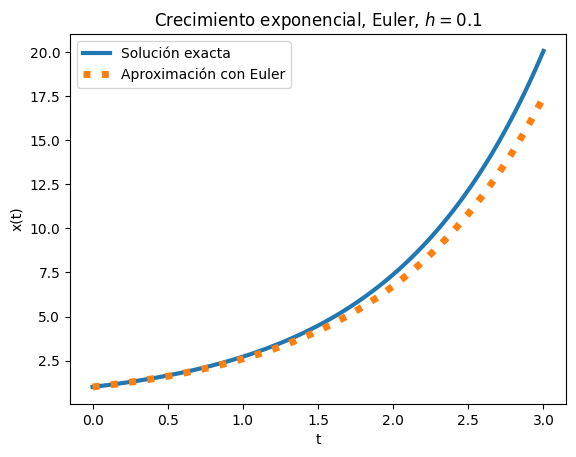

In [ ]:
plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t, w[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5) # en w se grafica la fila 0
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Crecimiento exponencial, Euler, $h=0.1$')
plt.legend()
plt.show()

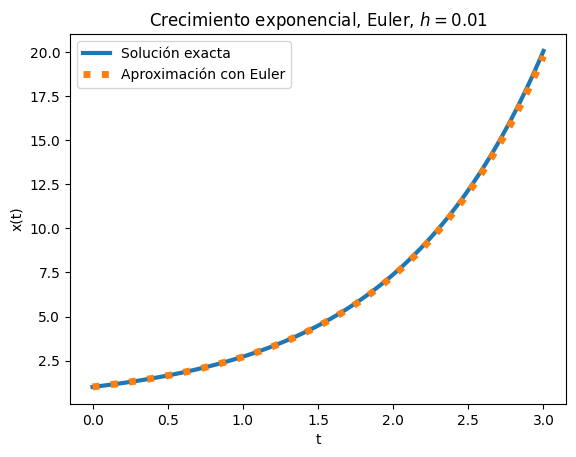

In [ ]:
# 3.3)
"""
Repetimos todo pero con h=0.01
"""
h=0.01

# solo hay que redefinir h y, por lo tanto, k

k=int((b-a)/h)

w2, t2 = integracion_ode(euler, f, xa, a, b, k, p)

# t_exacta y w_exacta siguen siendo las mismas

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t2, w2[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Crecimiento exponencial, Euler, $h=0.01$')
plt.legend()
plt.show()

## **Ejercicio 4)** Decaimiento exponencial

Considere la ODE

\begin{eqnarray}
x'(t)
&=&
-qx(t)+r
\end{eqnarray}

donde $q$ es una constante positiva y $r$ es una constante arbitraria.

**1)** Use el integrador ODE con el método de Euler para encontrar una aproximación numérica de la ODE arriba especificada.
Considere la condición inicial $x(0)=3$ e integre hasta $t=3$.
Utilice el paso de integración $h=0.1$ y los valores de los parámetros $q=2$ y $r=3$.

**2)** Grafique la trayectoria computada en el inciso anterior y, con el fin de comparar, grafique simultaneamente la correspondiente solución analítica derivada a continuación

\begin{eqnarray}
\frac{dx}{dt}
&=&
-qx+r
\\
-\frac{1}{q}\frac{du}{dt}
&=&
u,
\;\;\;\;
\;\;\;\;
\;\;\;\;
u=-qx+r
\\
\frac{du}{dt}
&=&
-qu
\\
u(t)
&=&
u(0)e^{-qt}
\\
-qx(t)+r
&=&
(-qx(0)+r)e^{-qt}
\\
x(t)
&=&
(x(0)-r/q)e^{-qt}+r/q
\end{eqnarray}

**3)** Repita para $h=0.01$.

**4)** Repita para $x(0)=1$.

In [ ]:
# 4.1)
"""
    seguimos los mismos pasos que antes
    tengo xa=3, t(0)=0=a, t(final)=3=b, q=2 y r=3 (esto iria a parametro), h=0.1
"""

def g(x, t, p):
  """
  q=p[0], r=p[1]
  """
  return -p[0]*np.array(x[0]) + p[1]

In [ ]:
xa=np.array([3])
a=0
b=3
p=np.array([2, 3])
h=0.1

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = integracion_ode(euler, g, xa, a, b, k, p)
w, t

(array([[3.        , 2.7       , 2.46      , 2.268     , 2.1144    ,
         1.99152   , 1.893216  , 1.8145728 , 1.75165824, 1.70132659,
         1.66106127, 1.62884902, 1.60307922, 1.58246337, 1.5659707 ,
         1.55277656, 1.54222125, 1.533777  , 1.5270216 , 1.52161728,
         1.51729382, 1.51383506, 1.51106805, 1.50885444, 1.50708355,
         1.50566684, 1.50453347, 1.50362678, 1.50290142, 1.50232114,
         1.50185691]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]))

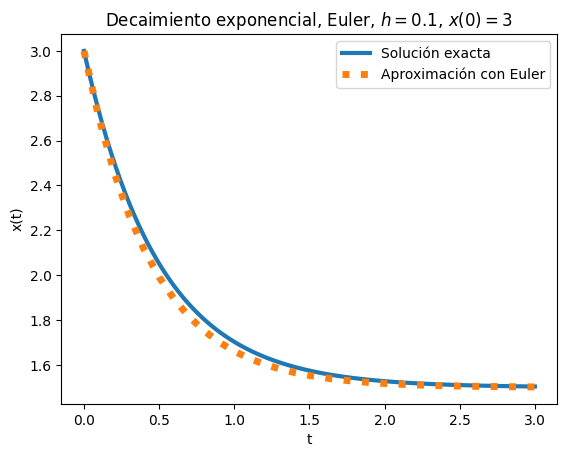

In [ ]:
# 4.2)
t_exacta = np.linspace(a, b, 100)
x_exacta = [(xa-p[1]/p[0])*np.exp(-p[0]*t)+p[1]/p[0] for t in t_exacta]

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t, w[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5) # en w se grafica la fila 0
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Decaimiento exponencial, Euler, $h=0.1$, $x(0)=3$')
plt.legend()
plt.show()

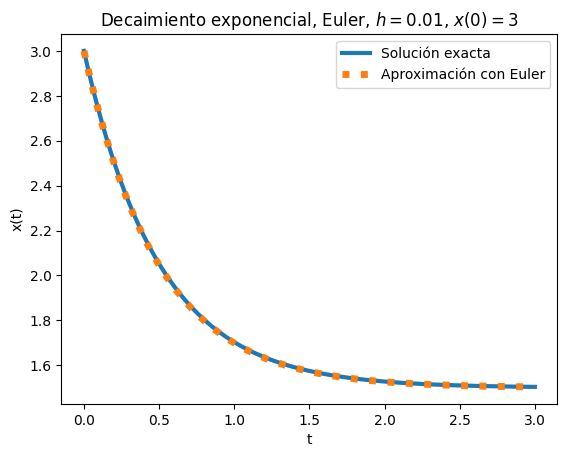

In [ ]:
# 4.3)
"""
Repetimos todo pero con h=0.01
"""
h=0.01

# solo hay que redefinir h y, por lo tanto, k

k=int((b-a)/h)

w2, t2 = integracion_ode(euler, g, xa, a, b, k, p)

# t_exacta y w_exacta siguen siendo las mismas

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t2, w2[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Decaimiento exponencial, Euler, $h=0.01$, $x(0)=3$')
plt.legend()
plt.show()

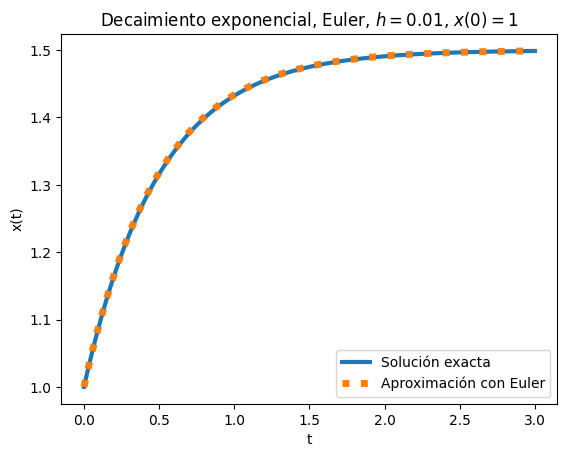

In [ ]:
# 4.4)
"""
Repetimos todo pero con xa=1, vamos a seguir con h=0.01
"""
xa=np.array([1])
w3, t3 = integracion_ode(euler, g, xa, a, b, k, p)

# ahora hay que cambiar x_exacta, pues cambia xa
x_exacta = [(xa-p[1]/p[0])*np.exp(-p[0]*t)+p[1]/p[0] for t in t_exacta]

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t3, w3[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Decaimiento exponencial, Euler, $h=0.01$, $x(0)=1$')
plt.legend()
plt.show()

## **Ejercicio 5)** Ecuación Logística

Considere la ODE

\begin{eqnarray}
x'(t)
&=&
rx(t)(1-x/K)
\end{eqnarray}

**1)** Integre numéricamente la anterior ODE utilizando el método de Euler, la condición inicial $x(0)=0.1$, hasta $t=5$, utilizando un paso de integración $h=0.1$, una tasa de reproducción $r=1$ y una capacidad de carga $K=1$.

**2)** Grafique la solución computada en el inciso anterior, comparandola con la solución analítica que se deriva a continuación

\begin{eqnarray}
\frac{dx}{dt}
&=&
rx(1-x/K)
\\
\frac{dx}{x(1-x/K)}
&=&
rdt
\\
\int_{x(0)}^{x(t)}\frac{dx}{x(1-x/K)}
&=&
rt
\\
\int_{x(0)}^{x(t)}dx\,\frac{1}{x}+\frac{1}{K-x}
&=&
rt
\\
\ln(x(t))-\ln(x(0))
-
\ln(K-x(t))
+
\ln(K-x(0))
&=&
rt
\\
\ln\frac{x(t)}{K-x(t)}
&=&
rt
+
\ln\frac{x(0)}{K-x(0)}
\\
\frac{x(t)}{K-x(t)}
&=&
f(t)
=
\frac{x(0)}{K-x(0)}e^{rt}
\\
x(t)
&=&
(K-x(t))f(t)
\\
x(t)(1+f(t))
&=&
Kf(t)
\\
x(t)
&=&
K\frac{f(t)}{1+f(t)}
=
K\frac{1}{1+\frac{1}{f(t)}}
\\
x(t)
&=&
K\left(1+\frac{K-x(0)}{x(0)}e^{-rt}\right)^{-1}
\end{eqnarray}

**3)** Repita para $x(0)=1.5$.

In [ ]:
# 5.1)

# x′(t)=rx(t)(1−x/K). Una tasa de reproducción r=1 y una capacidad de carga K=1.
"""
    tengo xa=0.1, t(0)=0=a, t(final)=5=b, r=1=p[0], K=1=p[1] (esto iria a parametro), h=0.1
"""

def f(x, t, p):
  return p[0]*np.array(x[0])*(1-np.array(x[0])/p[1])

In [ ]:
xa=np.array([0.1])
a=0
b=5
p=np.array([1, 1])
h=0.1

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = integracion_ode(euler, f, xa, a, b, k, p)
w, t

(array([[0.1       , 0.109     , 0.1187119 , 0.12917384, 0.14042263,
         0.15249305, 0.16541694, 0.17922236, 0.19393253, 0.2095648 ,
         0.22612953, 0.24362903, 0.26205642, 0.28139471, 0.30161588,
         0.32268026, 0.34453603, 0.36711912, 0.39035339, 0.41415115,
         0.43841415, 0.46303487, 0.48789823, 0.51288358, 0.53786698,
         0.56272359, 0.58733017, 0.61156751, 0.63532278, 0.65849155,
         0.6809796 , 0.70270424, 0.72359533, 0.74359585, 0.76266195,
         0.78076282, 0.79788005, 0.81400679, 0.82914677, 0.84331301,
         0.85652663, 0.8688155 , 0.88021302, 0.89075682, 0.90048773,
         0.90944869, 0.91768387, 0.92523789, 0.93215516, 0.93847935,
         0.94425294]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. ]

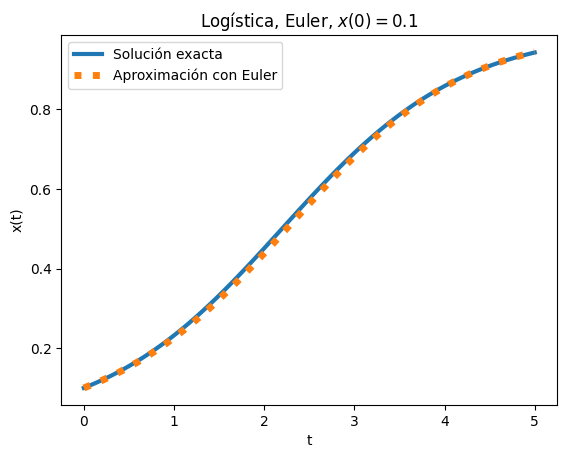

In [ ]:
# 5.2)

t_exacta = np.linspace(a, b, 100)
x_exacta = [p[1]*(1+((p[1]-xa)/xa)*np.exp(-p[0]*t))**(-1) for t in t_exacta]

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t, w[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5) # en w se grafica la fila 0
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Logística, Euler, $x(0)=0.1$')
plt.legend()
plt.show()

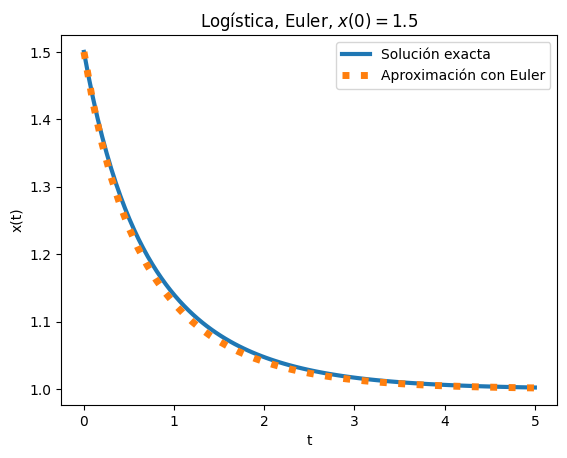

In [ ]:
# 5.3)
"""
 cambiamos el x(0), entonces debemos cambiar xa, redefinir w,t y x_exacta
"""

xa=np.array([1.5])
w2, t2 = integracion_ode(euler, f, xa, a, b, k, p)

x_exacta = [p[1]*(1+((p[1]-xa)/xa)*np.exp(-p[0]*t))**(-1) for t in t_exacta]

plt.plot(t_exacta, x_exacta, label="Solución exacta", linewidth=3)
plt.plot(t2, w2[0,:], label="Aproximación con Euler", linestyle="dotted", linewidth=5) # en w se grafica la fila 0
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Logística, Euler, $x(0)=1.5$')
plt.legend()
plt.show()

## **Ejercicio 6)** Oscilador armónico

### Redución del orden de una ODE

En general, una ODE tiene la siguiente forma

\begin{eqnarray}
y^{(n)}(t)
&=&
f(y(t),y'(t),y''(t),...,y^{(n-1)}(t),t)
\;\;\;\; (1)
\end{eqnarray}

donde $y^{(i)}$ denota la $i$-ésima derivada de $y$ respecto a $t$.
Dicha ODE es de dimensión $d$ si $x:\mathbb{R}\ni t\to y(t)\in \mathbb{R}^d$.
Además, se dice que es de orden $n$ porque involucra derivadas de $x$ de hasta orden $n$.

Una ODE de orden $n$ y dimensión $d$ como la de la ecuación $(1)$ siempre puede reducirse a una ODE de primero orden y dimensión $nd$ utilizando la siguiente transformación

\begin{eqnarray}
x_1:t\to x_1(t) &:=& y(t) \\
x_2:t\to x_2(t) &:=& y'(t) = x_1'(t) \\
x_3:t\to x_3(t) &:=& y''(t) = x_2'(t) \\
&...& \\
x_n:t\to x_n(t) &:=& y^{(n-1)}(t) = x_{n-1}'(t) \\
x_n':t\to x_n'(t) &=& y^{(n)}(t)
\end{eqnarray}

que vale para todo $t\in [a,b]$ de manera que la ecuación $(1)$ adopte la forma

\begin{eqnarray}
x_{1}'(t) &=& x_2(t) \\
x_{2}'(t) &=& x_3(t) \\
&...& \\
x_{n-1}'(t) &=& x_n(t) \\
x_n'(t) &=& f(x_1(t),x_2(t),x_3(t),...,x_{n}(t),t)
\end{eqnarray}

### El oscilador armónico

El oscilador armónico viene descripto por la siguiente ecuación diferencial ordinaria (ODE)

\begin{eqnarray}
y''(t) &=& -\alpha y(t)
\end{eqnarray}

Esta es una ODE de segundo orden, ya que aparece la derivada segunda de la función $x:t\to x(t)$.
La convertimos a una de primer orden definiendo $x_1=y$ y $x_2=y'$, obteniéndose

\begin{eqnarray}
x_1'(t) &=& x_2(t) \\
x_2'(t) &=& -\alpha x_1(t)
\end{eqnarray}

**1)** Utilice lo implementado en el ejecicio 2) para resolver en el intervalo de tiempo $[a,b]=[0,10]$ la ODE del oscilador armónico sujeto a las siguientes condiciones iniciales

\begin{eqnarray}
x_1(a) &=& y(a) = 1 \\
x_2(a) &=& y'(a) = 0
\end{eqnarray}

para $\alpha=3$ y usando un paso de integración $h=0.1$.

**2)** Grafique $x_1(t)$ vs $t$ y $x_2(t)$ vs $t$. No olvide agregar leyendas a los ejes y las curvas.
Use `np.scatter()` en vez de `np.plot()` para graficar usando puntos en vez de curvas.

**3)** Grafique $x_2(t)$ vs $x_1(t)$ paramétricamente en función de $t$.

In [ ]:
# 6.1)
"""
  Ahora tenemos 2 coordenadas, entonces el w va a tener 2 columnas (y tenemos 2 funciones (que podemos ponerlas en 1 pero con 2 columnas))
"""

def f(x, t, p):
  """
  x_1'=x_2=x[1] que lo ponemos en la primera coordenada
  x_2'=-alpha*x_1=-p[0]*x[0], donde alpha=p[0], que lo ponemos en la segunda coordenada
  """
  return np.array([x[1], -p[0]*x[0]])

In [ ]:
"""
intervalo de tiempo [a,b]=[0,10]; x_1(a)=y(a)=1, x_2(a)=y'(a)=0 entonces xa=[1, 0], p=alpha=3, h=0.1
"""
xa=np.array([1, 0])
a=0
b=10
p=np.array([3])
h=0.1

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = integracion_ode(euler, f, xa, a, b, k, p)

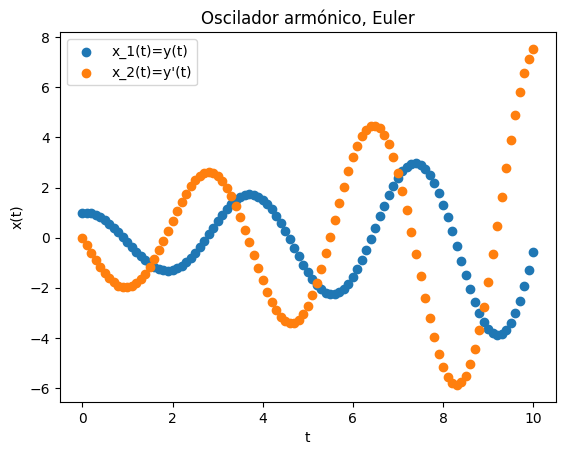

In [ ]:
# 6.2)
plt.scatter(t, w[0,:], label="x_1(t)=y(t)")
plt.scatter(t, w[1,:], label="x_2(t)=y'(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Oscilador armónico, Euler')
plt.legend()
plt.show()

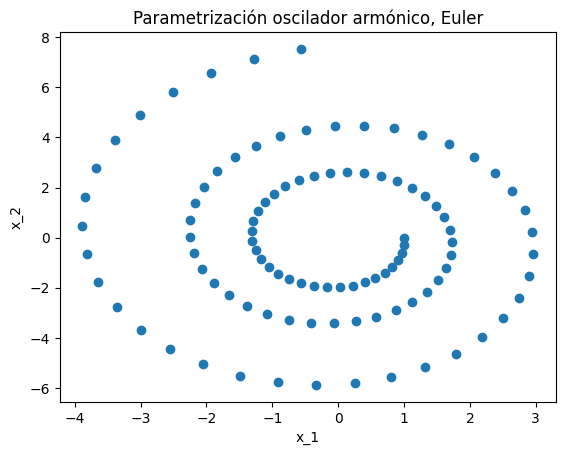

In [ ]:
# 6.3)
plt.scatter(w[0,:], w[1,:])
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title('Parametrización oscilador armónico, Euler')
plt.show()

## **Ejercicio 7)** Integrador de **RK4**

El método de Runge-Kutta de orden 4 utiliza la teoría de diferencias finitas para calcular la siguiente aproximación de orden 4ta de un paso de integración

A saber
\begin{eqnarray}
x(t+h)
&=&
x(t)
+
\frac{h}{6}
(k_1+2k_2+2k_3+k_4)
+
\mathcal{O}(h^5)
\end{eqnarray}

donde

\begin{eqnarray}
k_1 &=& f(x,t) \\
k_2 &=& f(x+hk_1/2,t+h/2) \\
k_3 &=& f(x+hk_2/2,t+h/2) \\
k_4 &=& f(x+hk_3,t+h)
\end{eqnarray}

**1)** Implemente el método de RK4.

**2)** Repita el ejercicio **6)** pero usando **RK4** en vez de **Euler**.

**3)** Nota alguna diferencia al comparar la solución obtenida con Euler y la solución obtenida con RK4?

In [ ]:
# 7.1)
def rk4(f, x, t, h, p):
  """
  calcula un paso de integración del método de runge kuta 4

  toma como argumentos:
    f: función del lado derecho de la ODE
    x: valor de R^n (puede haber más de 1 variable)
    t: tiempo, valor de R
    h: paso de integración
    p: vector de parámetros. Este vector sirve para casos en los que la función depende de otros parámetros que podamos ir cambiando.
        Por ejemplo, si f = q*x entonces puedo tener p=q y ver como cambia la función para distintos q.
  """
  k1=f(x, t, p)
  k2=f(x+h*k1/2,t+h/2, p)
  k3=f(x+h*k2/2,t+h/2, p)
  k4=f(x+h*k3,t+h, p)
  return x + (h/6)*(k1+2*k2+2*k3+k4)

In [ ]:
# 7.2)
"""
hagamos lo mismo que en el 6 pero con rk4
f, xa, a, b, p, h, k ya estan definidos
"""

w, t = integracion_ode(rk4, f, xa, a, b, k, p)
w

array([[ 1.        ,  0.9850375 ,  0.94059813,  0.86801172,  0.76945042,
         0.64786363,  0.50688982,  0.35074757,  0.18410939,  0.01196186,
        -0.16054355, -0.3282447 , -0.48612318, -0.62945455, -0.75394967,
        -0.85588309, -0.93220448, -0.98062997, -0.99971047, -0.98887499,
        -0.9484478 , -0.87963868, -0.78450673, -0.66589874, -0.52736402,
        -0.37304819, -0.20756909, -0.03587862,  0.13688544,  0.30555319,
         0.46507731,  0.61068411,  0.73801636,  0.8432637 ,  0.92327664,
         0.97566085,  0.99884875,  0.99214647,  0.95575458,  0.8907621 ,
         0.79911393,  0.6835526 ,  0.54753626,  0.39513515,  0.23090983,
         0.05977467, -0.11314915, -0.28268696, -0.44376541, -0.59156428,
        -0.72166076, -0.83016176, -0.91382044, -0.97013335, -0.99741536,
        -0.99485008, -0.96251429, -0.90137563, -0.81326366, -0.70081511,
        -0.56739497, -0.41699581, -0.25411825, -0.08363636,  0.08934825,
         0.25965908,  0.42219965,  0.572106  ,  0.7

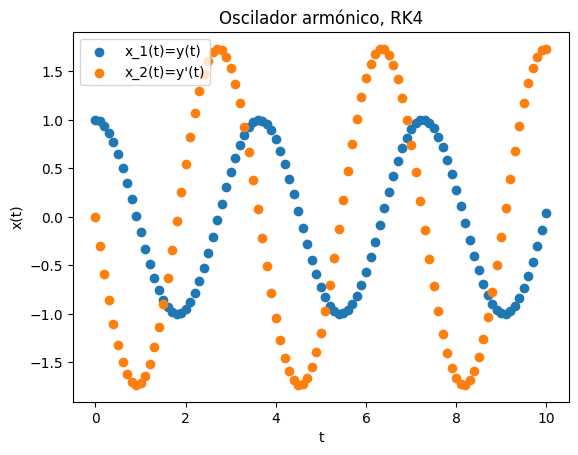

In [ ]:
plt.scatter(t, w[0,:], label="x_1(t)=y(t)")
plt.scatter(t, w[1,:], label="x_2(t)=y'(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Oscilador armónico, RK4')
plt.legend()
plt.show()

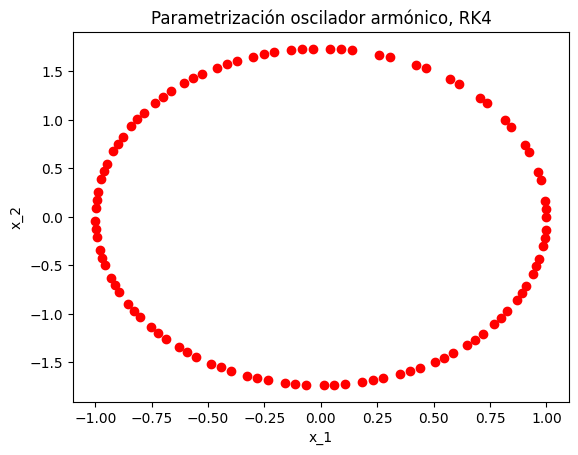

In [ ]:
plt.scatter(w[0,:], w[1,:], label="",linestyle='-',c='red')
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title('Parametrización oscilador armónico, RK4')
plt.show()

In [ ]:
""" Ahora da mejor, RK4 es mejor"""

' Ahora da mejor, RK4 es mejor'

## **Ejercicio 8)** Creando una "libreria" de integradores ODE

**1)** Exporte el actual notebook `redes-neuronales-2022-practico-4.ipynb` a `ode.py`.

**2)** Con su editor de texto favorito, elimine todo lo que sobra de `ode.py`. Deje, solamente, el código que:

* importa `numpy`.

* define la funcion `euler`.

* define la funcion `rk4`.

* define la funcion `integrador_ode`.

**3)** En google colab, suba el archiv `ode.py` anteriormente credo.

**4)** Importe la "libreria" `ode` escribiendo

    import ode

**5)** Pruebe la libreria `ode` escribiendo

    t,x = ode.integrador_ode(ode.rk4,f,xa,a,b,k,p)

In [ ]:
# 8.4)
import ode

In [ ]:
# 8.5)
x, tau = ode.integracion_ode(ode.rk4,f,xa,a,b,k,p)

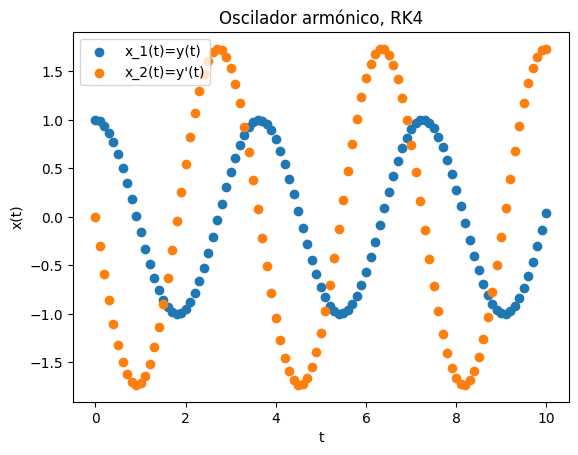

In [ ]:
# veamos que da
plt.scatter(tau, x[0,:], label="x_1(t)=y(t)")
plt.scatter(tau, x[1,:], label="x_2(t)=y'(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title('Oscilador armónico, RK4')
plt.legend()
plt.show()